# Chapter 2: Task Difficulty and Cognitive Overload

**Research Question:** How does intrinsic task difficulty impact human performance metrics (error rate, reaction time, and risk score)? Does high task complexity act as an independent driver of cognitive failure, or does its effect depend on the agent's baseline resources?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set clean graphic style
sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv("../data/human_performance_dataset.csv")

# Quick check on task_difficulty distribution
df['task_difficulty'].describe()

count    975425.000000
mean          0.624852
std           0.163074
min           0.300155
25%           0.490316
50%           0.625581
75%           0.751441
max           1.000000
Name: task_difficulty, dtype: float64

### 2.1 Distribution of Task Difficulty
Let's inspect the distribution and unique levels of task difficulty across the dataset to evaluate how complexity was modulated during the experimental tasks.

In [5]:
# Check unique values or quantiles of task difficulty
print(f"unique difficulty levels: {df['task_difficulty'].nunique()}")
print(df['task_difficulty'].value_counts().sort_index())

unique difficulty levels: 970368
task_difficulty
0.300155       1
0.300283       1
0.300346       1
0.300408       1
0.300432       1
            ... 
0.999989       1
0.999991       1
0.999991       1
0.999994       1
1.000000    5058
Name: count, Length: 970368, dtype: int64


Data Structure Audit: `task_difficulty` is a continuous numerical variable ranging from ~0.30 to 1.00 with over 970,000 unique values. To assess its impact, we must analyze its continuous distribution and consider binning it into discrete complexity tiers for group comparisons.

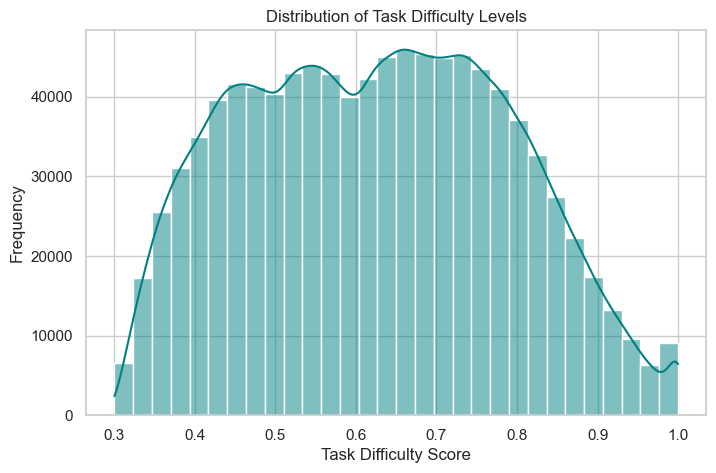

In [9]:
# Set figure size
plt.figure(figsize=(8, 5))

# Plot the distribution of task difficulty
sns.histplot(data=df, x='task_difficulty', bins=30,kde=True, color='teal')

#Add title and axis labels
plt.title("Distribution of Task Difficulty Levels")
plt.xlabel("Task Difficulty Score")
plt.ylabel("Frequency")

#Display the plot
plt.show()

### 2.2 Relationship Between Task Difficulty and Performance
To evaluate how increasing task complexity influences behavioral outcomes, we analyze the correlations and trendlines of `task_difficulty` against `error_rate` and `reaction_time`.

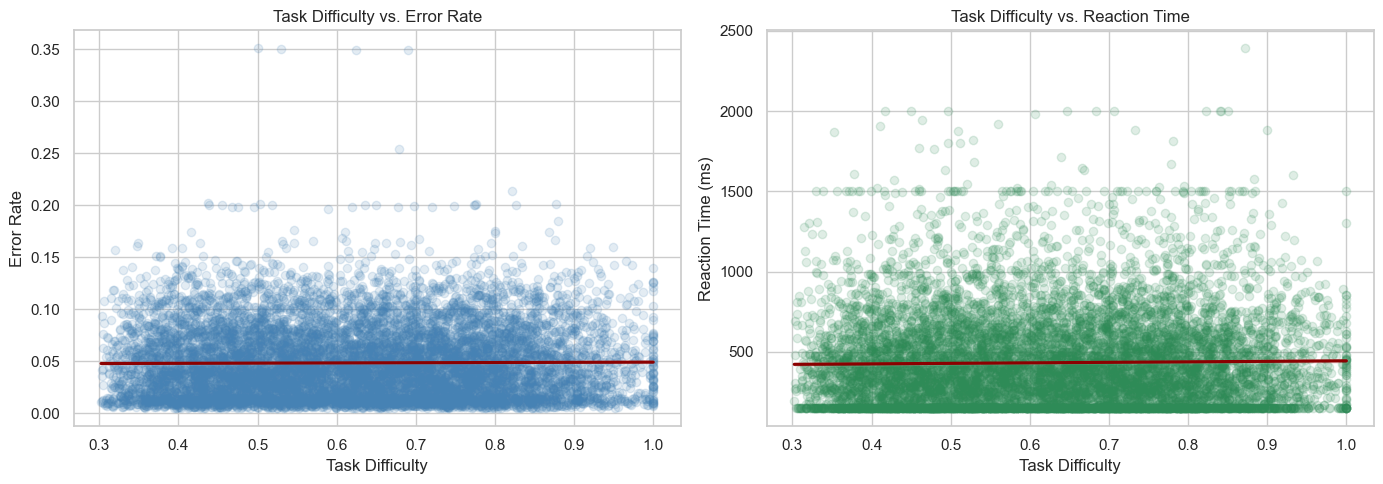

In [10]:
# Set up a 1x2 subplot figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Task Difficulty vs Error Rate (sampled to optimize rendering speed)
sample_df = df.sample(n=10000, random_state=42)

sns.regplot(data=sample_df, x='task_difficulty', y='error_rate', 
            scatter_kws={'alpha': 0.15, 'color': 'steelblue'}, 
            line_kws={'color': 'darkred'}, ax=axes[0])
axes[0].set_title("Task Difficulty vs. Error Rate")
axes[0].set_xlabel("Task Difficulty")
axes[0].set_ylabel("Error Rate")

# Plot Task Difficulty vs Reaction Time
sns.regplot(data=sample_df, x='task_difficulty', y='reaction_time', 
            scatter_kws={'alpha': 0.15, 'color': 'seagreen'}, 
            line_kws={'color': 'darkred'}, ax=axes[1])
axes[1].set_title("Task Difficulty vs. Reaction Time")
axes[1].set_xlabel("Task Difficulty")
axes[1].set_ylabel("Reaction Time (ms)")

plt.tight_layout()
plt.show()

### 2.3 Interpretation of Difficulty Trends
  **Flat Regression Slopes**: Both `error_rate` and `reaction_time` exhibit near-zero linear slopes across the full range of `task_difficulty` (0.30 to 1.00). Baseline performance remains centered around ~5% error rate and ~450 ms response latency regardless of nominal difficulty.
  
  **Absence of Direct Main Effect** :Isolated task complexity does not directly induce performance failures across the overall sample.
* **Moderation Hypothesis**: Because `task_difficulty` correlates with downstream risk metrics (`risk_score` r = 0.41) without degrading immediate behavioral execution, its effect is likely moderated by latent cognitive states (e.g., fatigue, regime shifts, or depleted resilience baseline).

### 2.4 Discretization (Binning) of Task Difficulty
To evaluate interaction effects across cognitive regimes, we segment the continuous `task_difficulty` variable into three quantile-based tiers: `Low`, `Medium`, and `High`.

In [11]:
# Bin task_difficulty into 3 quantiles
df['difficulty_tier'] = pd.qcut(
    df['task_difficulty'], 
    q=3, 
    labels=['Low', 'Medium', 'High']
)

# Verify tier counts and boundaries
print(df.groupby('difficulty_tier', observed=False)['task_difficulty'].agg(['count', 'min', 'max']))

                  count       min       max
difficulty_tier                            
Low              325142  0.300155  0.535699
Medium           325141  0.535700  0.709393
High             325142  0.709393  1.000000


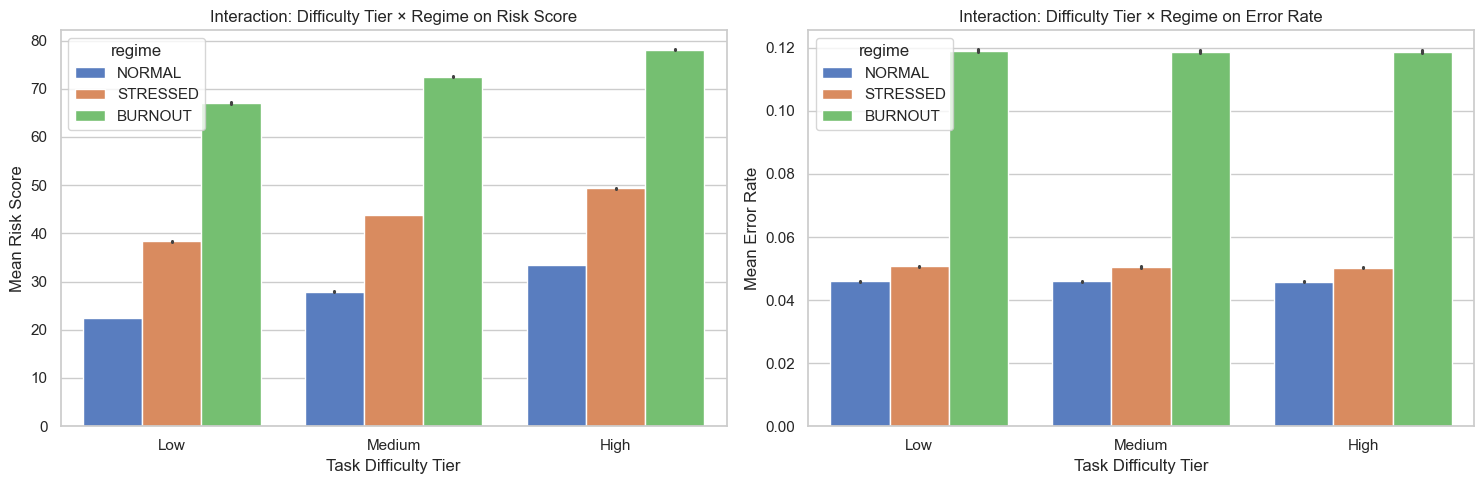

In [15]:
# Set figure layout
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Interaction on Risk Score
sns.barplot(
    data=df, 
    x='difficulty_tier', 
    y='risk_score', 
    hue='regime', 
    palette='muted', 
    ax=axes[0]
)
axes[0].set_title("Interaction: Difficulty Tier × Regime on Risk Score")
axes[0].set_xlabel("Task Difficulty Tier")
axes[0].set_ylabel("Mean Risk Score")

# 2. Interaction on Error Rate
sns.barplot(
    data=df, 
    x='difficulty_tier', 
    y='error_rate', 
    hue='regime', 
    palette='muted', 
    ax=axes[1]
)
axes[1].set_title("Interaction: Difficulty Tier × Regime on Error Rate")
axes[1].set_xlabel("Task Difficulty Tier")
axes[1].set_ylabel("Mean Error Rate")

plt.tight_layout()
plt.show()

### 2.6 Key Insights: Additive Risk vs. Invariant Error Rate
* **Error Rate Invariance across Tiers:** Task difficulty does not increase error rates within any cognitive state. Error generation is strictly driven by the operator's internal state, showing a sharp surge only when transitioning to `BURNOUT` (~12% vs. ~4.6% in `NORMAL`).

* **Additive Effect on Risk Score:** Unlike behavioral error rates, `risk_score` increases systematically with higher difficulty tiers (+11 points from Low to High) across all regimes.

* **Operational Implication:** High task complexity increases structural operational risk even when immediate operational execution (accuracy and response speed)remains stable.

### 2.7 Mission Failure Probability Analysis
We evaluate how intrinsic task difficulty and cognitive regime jointly influence the overall probability of mission failure.

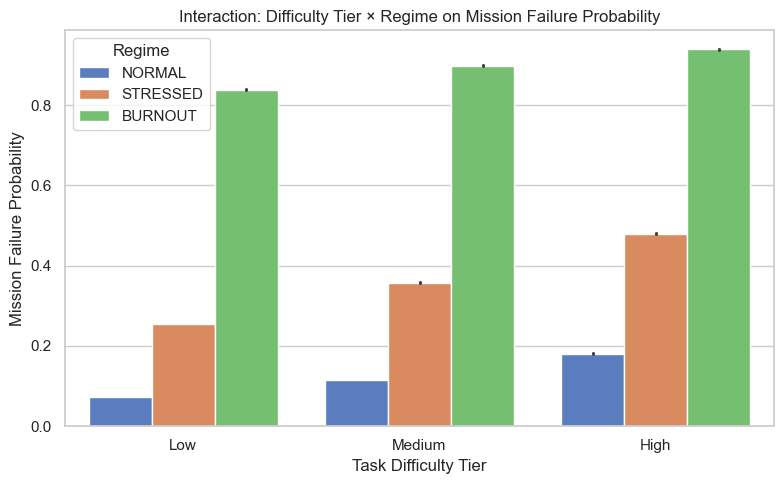

In [16]:
# Set figure size
plt.figure(figsize=(8, 5))

# Plot interaction on mission failure probability
sns.barplot(
    data=df, 
    x='difficulty_tier', 
    y='mission_failure_probability', 
    hue='regime', 
    palette='muted'
)
plt.title("Interaction: Difficulty Tier × Regime on Mission Failure Probability")
plt.xlabel("Task Difficulty Tier")
plt.ylabel("Mission Failure Probability")
plt.legend(title="Regime")

plt.tight_layout()
plt.show()

In [18]:
# Save the dataframe with the new difficulty_tier column
df.to_csv("../data/human_performance_dataset_processed.csv", index=False)
print("Dataset successfully saved with 'difficulty_tier' feature!")

Dataset successfully saved with 'difficulty_tier' feature!


### 2.8 Chapter Summary & Final Insights
* **Differential Sensitivity:** Task difficulty exhibits a negligible direct effect on raw behavioral metrics (`error_rate` and `reaction_time`), but acts as a strong linear contributor to system-level outcomes (`risk_score` and `mission_failure_probability`).

* **Cognitive State as Critical Bottleneck:** Operator regime remains the dominant determinant of mission success. High task difficulty escalates failure probability under stress (~48%), but in burnout states, failure rates exceed 80–94% regardless of task simplicity.

* **Dataset Export:** The engineered feature `difficulty_tier` has been saved to `human_performance_dataset_processed.csv` for downstream modeling.